### FRE-GY 6901, Volatility Models, Master of Science in Financial Engineering, NYU Tandon, Fall 2025
# Computing assignment 1 (Exercise 4 of Homework week 4)

### Due Date: 11:00 AM Monday, October 6, 2025
You should turn in the notebook in Brightspace.

The computing assignment is about the two-factor Bergomi model.

Please comment your code properly.

Before you turn in the notebook, press the "Run all cells" button in the toolbar, and make sure all the calculation results and graphs are produced correctly in a reasonable time frame, and then save the notebook.

In [ ]:
!pip install py_vollib


In [ ]:
import numpy as np

from scipy.stats import norm
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (4.8, 3.2)

from math import exp, sqrt, log, pi, sin, cos, atan, tan

In [ ]:
from py_vollib.black_scholes.implied_volatility import implied_volatility
vec_find_vol_rat = np.vectorize(implied_volatility)   # a better imp vol estimator based on P Jäckel Let's be rational

# The two-factor Bergomi model
The objective of the homework is to price SPX options, VIX futures, and VIX options in the two-factor Bergomi model

\begin{eqnarray}
S_t &=& S_0 \exp\left(\int_0^t \sqrt{\xi_s^s}dW_s - \frac{1}{2}\int_0^t \xi_s^s ds \right) \\
    X_t^j &=& e^{-k_j t} \int_0^t e^{k_j s} \, dZ^j_s, \qquad j\in\{1,2\} \\
\alpha_\theta &=& \left( (1-\theta)^2 +\theta^2+2 \rho_{12}\theta(1-\theta)\right)^{-1/2} \\
x_t^u &=& \alpha_\theta \left((1-\theta)e^{-k_1(u-t)}X_t^1 + \theta e^{-k_2(u-t)}X_t^2 \right) \\
\xi_t^u &=& \xi_0^u g^u(t,x_t^u) \;\; = \;\;\xi_0^u f^u(t,X_t^1,X_t^2) \\
g^u(t,x) &=& \exp\left(\omega x - \frac{\omega^2}{2}\chi(t,u)\right) \\
\chi(t,u) &=& \alpha_\theta^2\left( (1-\theta)^2e^{-2k_1(u-t)} \text{Var}(X_t^1) + \theta^2e^{-2k_2(u-t)} \text{Var}(X_t^2) \right. \\
&& \left. + 2\theta(1-\theta)e^{-(k_1+k_2)(u-t)}\text{Cov}(X_t^1,X_t^2)\right) \\
d\langle W,Z^1\rangle_t &=& \rho_{S1} dt \\
d\langle W,Z^2\rangle_t &=& \rho_{S2} dt \\
d\langle Z^1,Z^2\rangle_t &=& \rho_{12} dt \\
\end{eqnarray}

## Pricing SPX options

1. By doing a Cholesky decomposition, give a necessary and sufficient condition (*) on $\rho_{S1},\rho_{S2},\rho_{12}$ so that
$$\begin{bmatrix}1 & \rho_{S1} & \rho_{S2}\\ \rho_{S1} & 1 & \rho_{12} \\ \rho_{S2} & \rho_{12} & 1\end{bmatrix}$$
is a correlation matrix.

In [ ]:
 # Question 1
def check_correlation_matrix(rho_S1, rho_S2, rho_12):
    """
    Check if the correlation matrix is positive semi-definite.

    For a 3x3 correlation matrix:
    [[1,      rho_S1, rho_S2],
     [rho_S1, 1,      rho_12],
     [rho_S2, rho_12, 1     ]]

    Necessary and sufficient conditions:
    1. All correlations in [-1, 1]
    2. Determinant >= 0

    The determinant is: 1 + 2*rho_S1*rho_S2*rho_12 - rho_S1^2 - rho_S2^2 - rho_12^2

    Returns:
    bool: True if valid correlation matrix, False otherwise
    """
    # Check bounds
    if not (-1 <= rho_S1 <= 1 and -1 <= rho_S2 <= 1 and -1 <= rho_12 <= 1):
        return False

    # Check determinant (positive semi-definite condition)
    det = 1 + 2*rho_S1*rho_S2*rho_12 - rho_S1**2 - rho_S2**2 - rho_12**2

    return det >= 0

Below we describe a Monte Carlo simulation scheme for the two-factor Bergomi model.

First we discretize the interval $(0,T)$ into subintervals $(t_{i-1}, t_i)$, $1\leq i\leq n$, and set $\Delta t_i=t_i-t_{i-1}$.

The Ornstein-Uhlenbeck process $X^j$ is explicitly solvable:
\begin{equation}
X^j_{t_i}=e^{-k_j\Delta t_i}X^j_{t_{i-1}}+\int_{t_{i-1}}^{t_i} e^{-k_j\left(t_i-s\right)}dZ_s^{j}.
\end{equation}
so that paths of $X^j$ can be simulated exactly.

To simulate the spot process $S$, we use the Euler scheme on the log (by abuse of notation, below, S will denote the Euler scheme, not the true asset price process):
$$\log S_{t_i}-\log S_{t_{i-1}}=-\frac{1}{2}\xi_{t_{i-1}}^{t_{i-1}}\Delta t_i+\sqrt{\xi_{t_{i-1}}^{t_{i-1}}}\int_{t_{i-1}}^{t_i}dW_t$$

Thus given $(S_{t_{i-1}},X^1_{t_{i-1}},X^2_{t_{i-1}})$, $(\log S_{t_i},X^1_{t_i},X^2_{t_i})$ is a Gaussian vector.

2. Compute the mean vector and covariance matrix of this Gaussian vector.

This is what we will use to iteratively simulate $(\log S_{t_i},X^1_{t_i},X^2_{t_i})$.

3. Fill in the blanks in the code below.


In [ ]:
# Question 2

def compute_gaussian_statistics(S_prev, X1_prev, X2_prev, dt, k_1, k_2,
                                theta, alpha, vov, xi_0, chi_val,
                                rho_sx1, rho_sx2, rho_x1x2):
    """
    Compute mean vector and covariance matrix for (log(S_t), X1_t, X2_t).

    Given state at t_{i-1}, compute distribution at t_i.

    The evolution equations are:
    - X1_t = exp(-k_1*dt)*X1_{t-1} + integral[exp(-k_1*(t-s))dZ1_s]
    - X2_t = exp(-k_2*dt)*X2_{t-1} + integral[exp(-k_2*(t-s))dZ2_s]
    - log(S_t) = log(S_{t-1}) - 0.5*xi_{t-1}*dt + sqrt(xi_{t-1})*integral[dW_s]

    Returns:
    mean: np.array of shape (3,) - mean of [log(S), X1, X2]
    cov: np.array of shape (3,3) - covariance matrix
    """
    # Compute instantaneous volatility at previous time step
    X_prev = alpha * ((1 - theta) * X1_prev + theta * X2_prev)
    inst_vol_prev = sqrt(xi_0) * np.exp(vov * X_prev / 2 - vov**2 / 4 * chi_val)

    # Mean vector
    mean = np.array([
        log(S_prev) - 0.5 * inst_vol_prev**2 * dt,  # E[log(S_t)]
        np.exp(-k_1 * dt) * X1_prev,                  # E[X1_t]
        np.exp(-k_2 * dt) * X2_prev                   # E[X2_t]
    ])

    # Covariance helper function
    def covar(k_i, k_j, rho, t):
        """Covariance between OU processes"""
        if k_i + k_j == 0:
            return rho * t
        return rho * (1 - np.exp(-(k_i + k_j) * t)) / (k_i + k_j)

    # Variances
    var_X1 = covar(k_1, k_1, 1.0, dt)
    var_X2 = covar(k_2, k_2, 1.0, dt)

    # Covariance between X1 and X2
    cov_X1_X2 = covar(k_1, k_2, rho_x1x2, dt)

    # Covariance between log(S) and X1: Cov(int dW_s, int exp(-k_1*(t-s))dZ1_s)
    # = rho_sx1 * sqrt(dt * var_X1)
    cov_logS_X1 = rho_sx1 * sqrt(dt) * sqrt(var_X1) * inst_vol_prev

    # Covariance between log(S) and X2
    cov_logS_X2 = rho_sx2 * sqrt(dt) * sqrt(var_X2) * inst_vol_prev

    # Variance of log(S)
    var_logS = inst_vol_prev**2 * dt

    # Construct covariance matrix
    cov = np.array([
        [var_logS,    cov_logS_X1, cov_logS_X2],
        [cov_logS_X1, var_X1,      cov_X1_X2  ],
        [cov_logS_X2, cov_X1_X2,   var_X2     ]
    ])

    return mean, cov

In [ ]:
# Question 3
def two_factor_bergomi_mc(vov,k_1,k_2,theta,rho_sx1,rho_sx2,rho_x1x2,xi_0,n_steps,N_sims):
    #xi_0 is assumed costant: just a number
    #vov is the vol of variance omega

    # Check correlation matrix validity
    if not check_correlation_matrix(rho_sx1, rho_sx2, rho_x1x2):
        print("Correlation matrix is not valid")

    tt = np.linspace(0., T, n_steps + 1)
    dt = T/n_steps

    # covariance function for OU process
    def covar(k_1,k_2,rho,t):
        return rho*(1-np.exp(-(k_1+k_2)*t))/(k_1+k_2)

    # variance for volatility process
    def chi_func(k_1,k_2,theta,rho_x1x2,alpha,t): # computes chi(t,t)
        chi = (1-theta)**2*covar(k_1,k_1,1.0,t)+theta**2*covar(k_2,k_2,1.0,t)+\
        2*theta*(1-theta)*covar(k_1,k_2,rho_x1x2,t)

        return alpha**2*chi

    # normalize
    alpha = 1/sqrt((1-theta)**2+theta**2+2*rho_x1x2*theta*(1-theta))

    # chi at all time steps for variance normalization
    chi = chi_func(k_1,k_2,theta,rho_x1x2,alpha,tt)

    X_1 = np.zeros((n_steps+1,N_sims))
    X_2 = np.zeros((n_steps+1,N_sims))
    X = np.zeros((n_steps+1,N_sims))
    inst_vol = np.zeros((n_steps+1,N_sims))
    logS = np.zeros((n_steps+1,N_sims))
    logS[0] = log(S_0)
    inst_vol[0] = sqrt(xi_0)

    # Cholesky Decomposition for correlated random variables
    corr_matrix = np.array([[1, rho_sx1, rho_sx2],
                            [rho_sx1, 1, rho_x1x2],
                            [rho_sx2, rho_x1x2, 1]])
    L = np.linalg.cholesky(corr_matrix)

    for i in range(n_steps):
        # independent N(0,1) random numbers for factor increments
        z1, z2, z3 = np.random.normal(size=(3,N_sims))
        X_1[i+1] = X_1[i]*np.exp(-k_1*dt) + sqrt(covar(k_1,k_1,1,dt))*z1
        X_2[i+1] = X_2[i]*np.exp(-k_2*dt) + sqrt(covar(k_2,k_2,1,dt))*z2

        # mix factors Bergomi
        X[i+1] = alpha*((1-theta)*X_1[i+1] + theta*X_2[i+1])
        inst_vol[i+1] = sqrt(xi_0)*np.exp(vov*X[i+1]/2-vov**2/4*chi[i+1])

        logS[i+1] = logS[i] + (-0.5 * inst_vol[i+1]**2) * dt + inst_vol[i] * np.sqrt(dt) * z3

    return np.exp(logS[-1])

In [ ]:
vov = 4
k_1 = 20
k_2 = 1.5
theta = 0.75
xi_0 = 0.025
rho_sx1,rho_sx2,rho_x1x2 = -0.8, -0.7, 0.7
T = 1

In [ ]:
S_0 = 100

In [ ]:
n_steps = 500
N_sims = 100000

In [ ]:
ST = two_factor_bergomi_mc(vov,k_1,k_2,theta,rho_sx1, rho_sx2, rho_x1x2,xi_0,n_steps,N_sims)

In [ ]:
lm = np.linspace(-0.6,0.4,100) # log-moneyness
strike_array = np.exp(lm)*S_0

In [ ]:
opt_price = np.average(np.maximum(ST-strike_array.reshape(-1,1),0),axis=1)
iv = vec_find_vol_rat(opt_price, S_0, strike_array, T, 0, 'c')

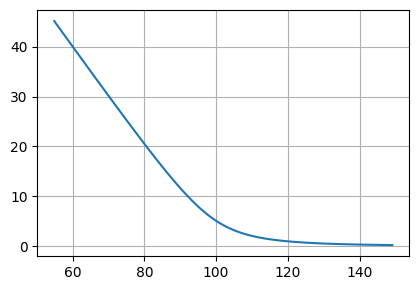

In [ ]:
plt.plot(strike_array,opt_price)
plt.grid()

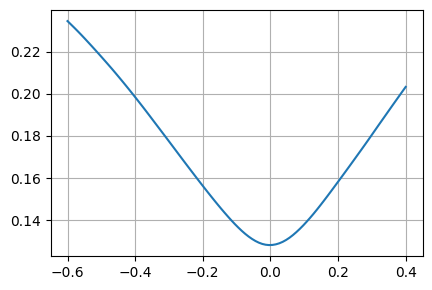

In [ ]:
plt.plot(lm,iv)
plt.grid()

4. Vary the parameters vov, k_1, k_2, theta, rho_sx1, rho_sx2, rho_x1x2 and T and comment on the impact on the smile

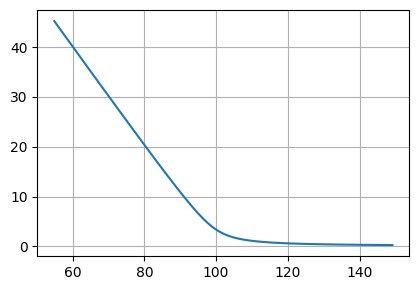

In [ ]:
# Question 4

vov = 7 # increasing vov
k_1 = 20
k_2 = 1.5
theta = 0.75
xi_0 = 0.025
rho_sx1,rho_sx2,rho_x1x2 = -0.8, -0.7, 0.7
T = 1

S_0 = 100

n_steps = 500
N_sims = 100000

ST = two_factor_bergomi_mc(vov,k_1,k_2,theta,rho_sx1, rho_sx2, rho_x1x2,xi_0,n_steps,N_sims)

lm = np.linspace(-0.6,0.4,100) # log-moneyness
strike_array = np.exp(lm)*S_0

opt_price = np.average(np.maximum(ST-strike_array.reshape(-1,1),0),axis=1)
iv = vec_find_vol_rat(opt_price, S_0, strike_array, T, 0, 'c')

plt.plot(strike_array,opt_price)
plt.grid()

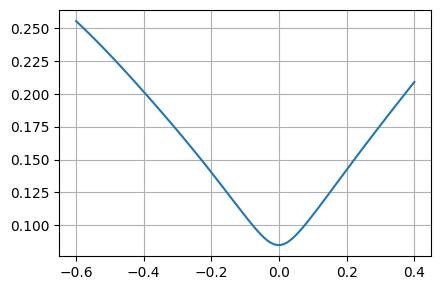

In [ ]:
plt.plot(lm,iv)
plt.grid()

Increasing Volatility of Variance: steeper, more convex smile

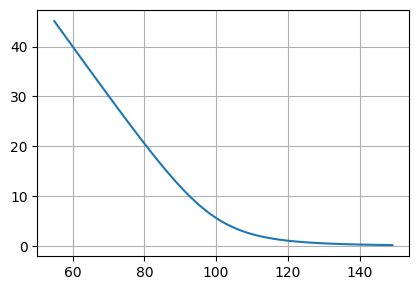

In [ ]:
vov = 3 # decreasing vov
k_1 = 20
k_2 = 1.5
theta = 0.75
xi_0 = 0.025
rho_sx1,rho_sx2,rho_x1x2 = -0.8, -0.7, 0.7
T = 1

S_0 = 100

n_steps = 500
N_sims = 100000

ST = two_factor_bergomi_mc(vov,k_1,k_2,theta,rho_sx1, rho_sx2, rho_x1x2,xi_0,n_steps,N_sims)

lm = np.linspace(-0.6,0.4,100) # log-moneyness
strike_array = np.exp(lm)*S_0

opt_price = np.average(np.maximum(ST-strike_array.reshape(-1,1),0),axis=1)
iv = vec_find_vol_rat(opt_price, S_0, strike_array, T, 0, 'c')

plt.plot(strike_array,opt_price)
plt.grid()

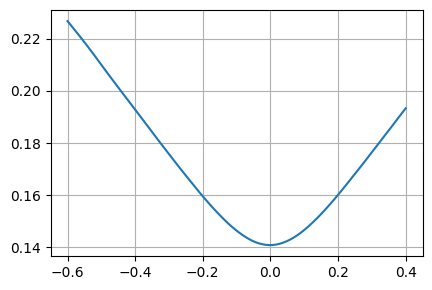

In [ ]:
plt.plot(lm,iv)
plt.grid()

Decreasing Volatility of Variance - flatter smile

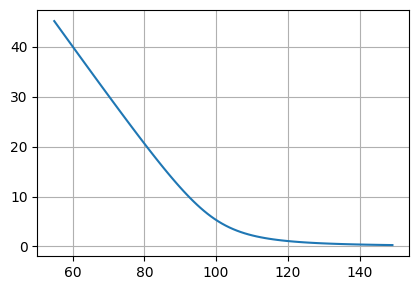

In [ ]:
vov = 4
k_1 = 100 # increasing k_1
k_2 = 1.5
theta = 0.75
xi_0 = 0.025
rho_sx1,rho_sx2,rho_x1x2 = -0.8, -0.7, 0.7
T = 1

S_0 = 100

n_steps = 500
N_sims = 100000

ST = two_factor_bergomi_mc(vov,k_1,k_2,theta,rho_sx1, rho_sx2, rho_x1x2,xi_0,n_steps,N_sims)

lm = np.linspace(-0.6,0.4,100) # log-moneyness
strike_array = np.exp(lm)*S_0

opt_price = np.average(np.maximum(ST-strike_array.reshape(-1,1),0),axis=1)
iv = vec_find_vol_rat(opt_price, S_0, strike_array, T, 0, 'c')

plt.plot(strike_array,opt_price)
plt.grid()

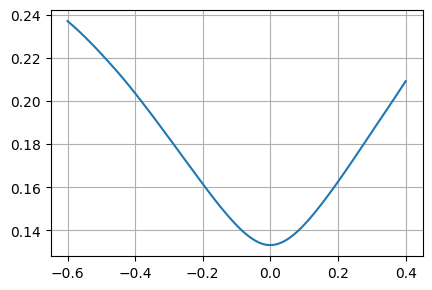

In [ ]:
plt.plot(lm,iv)
plt.grid()

Increasing k_1: no visible change, probably because the 2-factor model is designed so that k_1 affects short-term smile dynamics while k_2 affects long-term smile behavior. At T=1 year with theta=0.75, you're in a regime dominated by the slow factor!

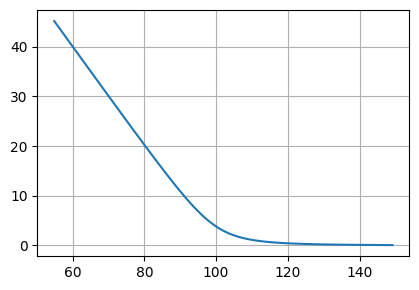

In [ ]:
vov = 4
k_1 = 0.1 # decreasing k_1
k_2 = 1.5
theta = 0.75
xi_0 = 0.025
rho_sx1,rho_sx2,rho_x1x2 = -0.8, -0.7, 0.7
T = 1

S_0 = 100

n_steps = 500
N_sims = 100000

ST = two_factor_bergomi_mc(vov,k_1,k_2,theta,rho_sx1, rho_sx2, rho_x1x2,xi_0,n_steps,N_sims)

lm = np.linspace(-0.6,0.4,100) # log-moneyness
strike_array = np.exp(lm)*S_0

opt_price = np.average(np.maximum(ST-strike_array.reshape(-1,1),0),axis=1)
iv = vec_find_vol_rat(opt_price, S_0, strike_array, T, 0, 'c')

plt.plot(strike_array,opt_price)
plt.grid()

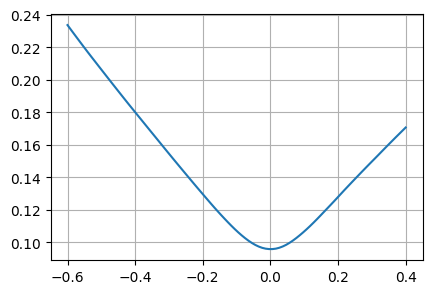

In [ ]:
plt.plot(lm,iv)
plt.grid()

Decreasing k_1: More curved smile

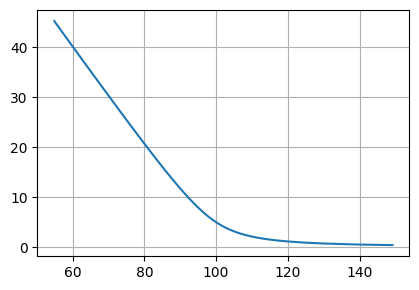

In [ ]:
vov = 4
k_1 = 20
k_2 = 1.5
theta = 1 # increasing theta
xi_0 = 0.025
rho_sx1,rho_sx2,rho_x1x2 = -0.8, -0.7, 0.7
T = 1

S_0 = 100

n_steps = 500
N_sims = 100000

ST = two_factor_bergomi_mc(vov,k_1,k_2,theta,rho_sx1, rho_sx2, rho_x1x2,xi_0,n_steps,N_sims)

lm = np.linspace(-0.6,0.4,100) # log-moneyness
strike_array = np.exp(lm)*S_0

opt_price = np.average(np.maximum(ST-strike_array.reshape(-1,1),0),axis=1)
iv = vec_find_vol_rat(opt_price, S_0, strike_array, T, 0, 'c')

plt.plot(strike_array,opt_price)
plt.grid()

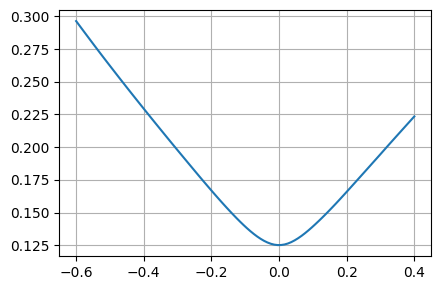

In [ ]:
plt.plot(lm,iv)
plt.grid()

Increasing theta : changes tilt, left-right symmetry, more weight on slow factor k_2

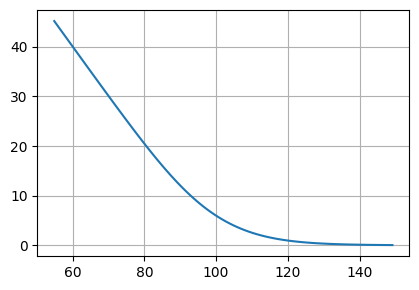

In [ ]:
vov = 4
k_1 = 20
k_2 = 1.5
theta = 0.2 # decreasing theta
xi_0 = 0.025
rho_sx1,rho_sx2,rho_x1x2 = -0.8, -0.7, 0.7
T = 1

S_0 = 100

n_steps = 500
N_sims = 100000

ST = two_factor_bergomi_mc(vov,k_1,k_2,theta,rho_sx1, rho_sx2, rho_x1x2,xi_0,n_steps,N_sims)

lm = np.linspace(-0.6,0.4,100) # log-moneyness
strike_array = np.exp(lm)*S_0

opt_price = np.average(np.maximum(ST-strike_array.reshape(-1,1),0),axis=1)
iv = vec_find_vol_rat(opt_price, S_0, strike_array, T, 0, 'c')

plt.plot(strike_array,opt_price)
plt.grid()

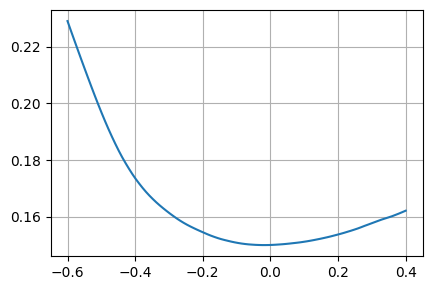

In [ ]:
plt.plot(lm,iv)
plt.grid()

Decreasing theta : changes tilt, more weight on fast factor k_1

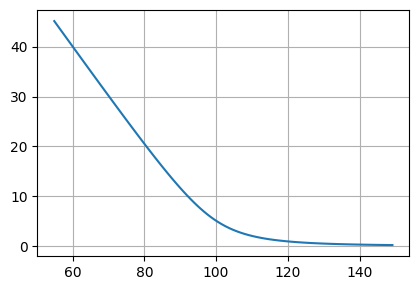

In [ ]:
vov = 4
k_1 = 20
k_2 = 1.5
theta = 0.75
xi_0 = 0.025
rho_sx1,rho_sx2,rho_x1x2 = 0.8, 0.7, 0.7 # positive correlations
T = 1

S_0 = 100

n_steps = 500
N_sims = 100000

ST = two_factor_bergomi_mc(vov,k_1,k_2,theta,rho_sx1, rho_sx2, rho_x1x2,xi_0,n_steps,N_sims)

lm = np.linspace(-0.6,0.4,100) # log-moneyness
strike_array = np.exp(lm)*S_0

opt_price = np.average(np.maximum(ST-strike_array.reshape(-1,1),0),axis=1)
iv = vec_find_vol_rat(opt_price, S_0, strike_array, T, 0, 'c')

plt.plot(strike_array,opt_price)
plt.grid()

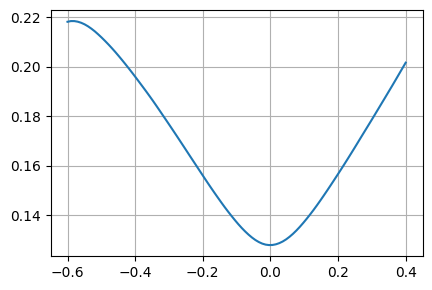

In [ ]:
plt.plot(lm,iv)
plt.grid()

Positive correlations : create positive skew, right wing tilts up instead of left wing. OTM calls more expensive than OTM puts

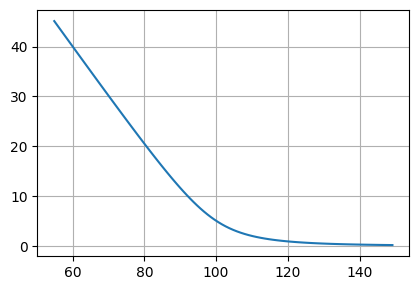

In [ ]:
vov = 4
k_1 = 20
k_2 = 1.5
theta = 0.75
xi_0 = 0.025
rho_sx1,rho_sx2,rho_x1x2 = 0, 0, 0.7 # zero correlations
T = 1

S_0 = 100

n_steps = 500
N_sims = 100000

ST = two_factor_bergomi_mc(vov,k_1,k_2,theta,rho_sx1, rho_sx2, rho_x1x2,xi_0,n_steps,N_sims)

lm = np.linspace(-0.6,0.4,100) # log-moneyness
strike_array = np.exp(lm)*S_0

opt_price = np.average(np.maximum(ST-strike_array.reshape(-1,1),0),axis=1)
iv = vec_find_vol_rat(opt_price, S_0, strike_array, T, 0, 'c')

plt.plot(strike_array,opt_price)
plt.grid()

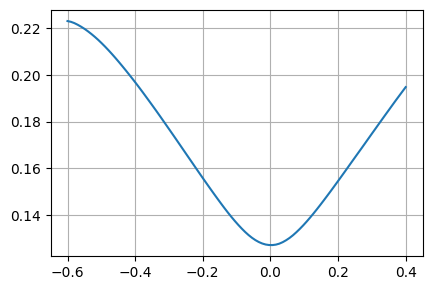

In [ ]:
plt.plot(lm,iv)
plt.grid()

Factors are uncorrelated : remove skew, smile nearly symmetric, no leverage effect

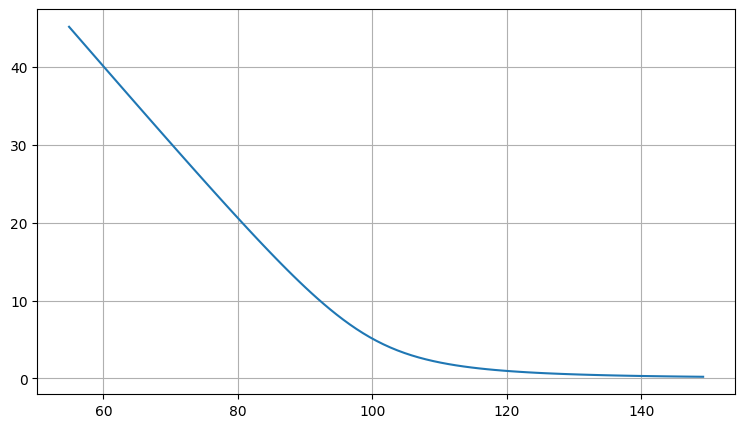

In [ ]:
vov = 4
k_1 = 20
k_2 = 1.5
theta = 0.75
xi_0 = 0.025
rho_sx1,rho_sx2,rho_x1x2 = -0.9, -0.9, 0.7 # extreme negative correlations
T = 1

S_0 = 100

n_steps = 500
N_sims = 100000

ST = two_factor_bergomi_mc(vov,k_1,k_2,theta,rho_sx1, rho_sx2, rho_x1x2,xi_0,n_steps,N_sims)

lm = np.linspace(-0.6,0.4,100) # log-moneyness
strike_array = np.exp(lm)*S_0

opt_price = np.average(np.maximum(ST-strike_array.reshape(-1,1),0),axis=1)
iv = vec_find_vol_rat(opt_price, S_0, strike_array, T, 0, 'c')

plt.plot(strike_array,opt_price)
plt.grid()

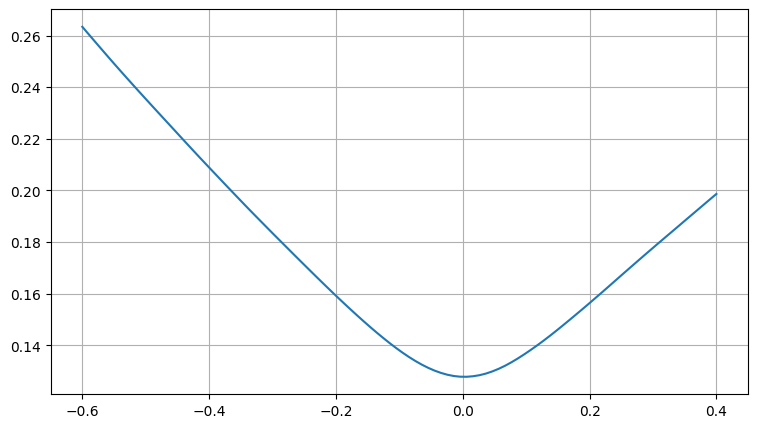

In [ ]:
plt.plot(lm,iv)
plt.grid()

Extreme negative factors : very steep left wing. OTM puts become much more expensive, reflecting dramatic negative skew as observed during market stress

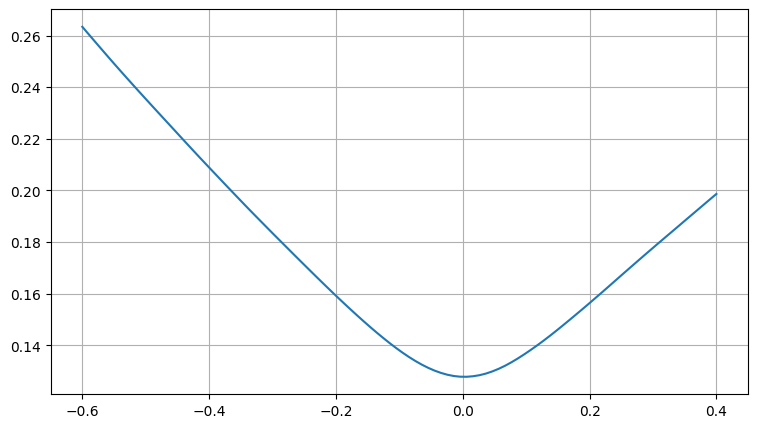

In [ ]:
plt.plot(lm,iv)
plt.grid()

Negative factor correlation : more curved smile

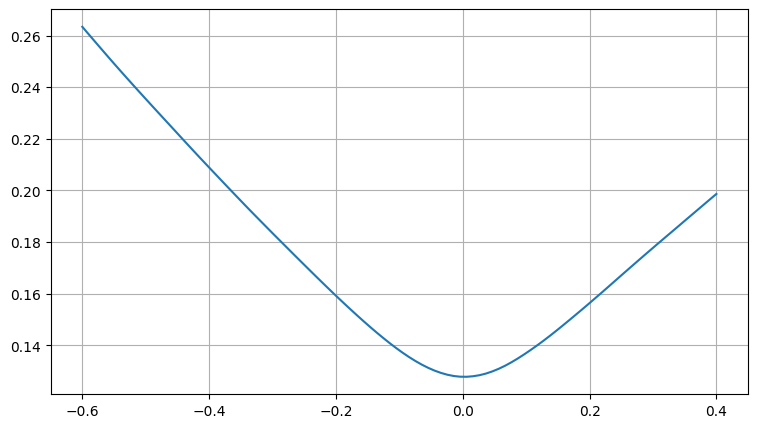

In [ ]:
plt.plot(lm,iv)
plt.grid()

Factors are uncorrelated : The smile shape is a mix of the two factors' contributions

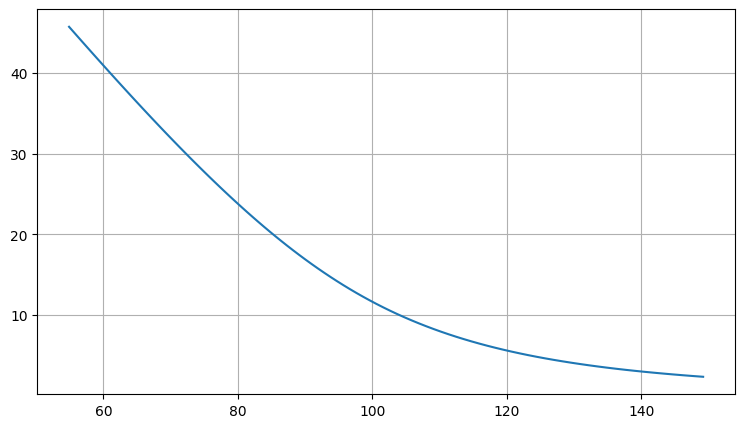

In [ ]:
vov = 4
k_1 = 20
k_2 = 1.5
theta = 0.75
xi_0 = 0.025
rho_sx1,rho_sx2,rho_x1x2 = -0.8, -0.7, 0.7
T = 5 # increasing maturity

S_0 = 100

n_steps = 500
N_sims = 100000

ST = two_factor_bergomi_mc(vov,k_1,k_2,theta,rho_sx1, rho_sx2, rho_x1x2,xi_0,n_steps,N_sims)

lm = np.linspace(-0.6,0.4,100) # log-moneyness
strike_array = np.exp(lm)*S_0

opt_price = np.average(np.maximum(ST-strike_array.reshape(-1,1),0),axis=1)
iv = vec_find_vol_rat(opt_price, S_0, strike_array, T, 0, 'c')

plt.plot(strike_array,opt_price)
plt.grid()

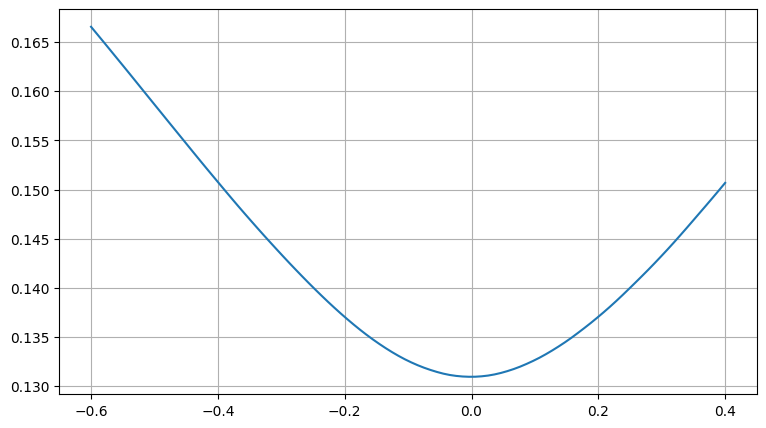

In [ ]:
plt.plot(lm,iv)
plt.grid()

Increasing T : flatter smile (term structure)

## Pricing VIX options

Recall that in variance curve models,
$$\text{VIX}^2_T = \frac{1}{\tau}\int_T^{T+\tau} \xi_T^u du$$
where $\tau=30/365$ (30 days). As a result, in the two-factor Bergomi model, there exists a function $\psi$ such that
$$\text{VIX}_T = \psi(T,X_T^1,X_T^2)$$

5. Write down the function $\psi$.

Since the vector $(X_T^1,X_T^2)$ is Gaussian, the price $\mathbb{E}[h(\text{VIX}_T)]$ of a VIX option $h(\text{VIX}_T)$ can very efficiently be estimated by a Gauss-Hermite quadrature; see
https://en.wikipedia.org/wiki/Gaussian_quadrature and
https://numpy.org/doc/stable/reference/generated/numpy.polynomial.hermite.hermgauss.html

6. Using this method, price a VIX future maturing at $T$ (choose $T=1/12$ (1 month), $2/12$, $3/12$, $4/12$) and VIX call options with the same maturity; take strikes with log-moneyness from -0.2 to 2.5, based on the price of the VIX future. Vary the number of points in the quadrature: 10, 20, 30, 50. What do you observe? Using 50 points in the quadrature, plot the VIX smile, using the Black formula (with spot value the value of the VIX future) to compute the VIX implied volatilities.

7. Comment on the impact of the vol-of-vol on the price of the VIX future and on the VIX implied volatilities. In the one-factor Bergomi model ($\theta=0$), comment on the impact of the mean reversion on the VIX implied volatilities: take $k_1 = 1,5,10,30,60,100$.

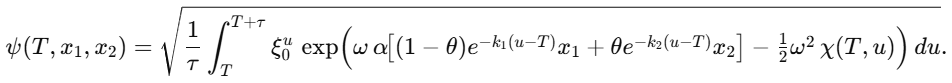

In [ ]:
import numpy as np
from numpy.polynomial.hermite import hermgauss

# Gauss–Hermite nodes and weights
n_quad = 20
z, w = hermgauss(n_quad)

def psi(T, x1, x2, xi0_u, vov, alpha, theta, k1, k2, chi_func, tau):
    """Compute ψ(T, x1, x2)."""
    u_vals = np.linspace(T, T + tau, 100)
    integrand = xi0_u(u_vals) * np.exp(
        vov * alpha * ((1 - theta) * np.exp(-k1 * (u_vals - T)) * x1 +
                       theta * np.exp(-k2 * (u_vals - T)) * x2)
        - 0.5 * vov**2 * chi_func(T, u_vals)
    )
    return np.sqrt((1 / tau) * np.trapz(integrand, u_vals))

# Example: expectation of a call payoff on VIX_T
def vix_option_price(T, xi0_u, vov, alpha, theta, k1, k2, chi_func,
                     tau, m, Sigma, K, payoff):
    """E[h(VIX_T)] by 2D Gauss–Hermite quadrature."""
    # mean and covariance of (X_T^1, X_T^2)
    m1, m2 = m
    s1 = np.sqrt(Sigma[0,0])
    s2 = np.sqrt(Sigma[1,1])
    rho = Sigma[0,1] / (s1 * s2)
    price = 0.0
    for i in range(n_quad):
        for j in range(n_quad):
            x1 = m1 + np.sqrt(2)*s1*z[i]
            x2 = m2 + np.sqrt(2)*s2*(rho*z[i] + np.sqrt(1-rho**2)*z[j])
            vix = psi(T, x1, x2, xi0_u, vov, alpha, theta, k1, k2, chi_func, tau)
            price += w[i]*w[j]*payoff(vix)
    return price / np.pi


Processing T = 0.083333


/tmp/ipython-input-2484314054.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(integrand, u_vals)


  Ref VIX future (50 nodes) = 0.153621
Processing T = 0.166667
  Ref VIX future (50 nodes) = 0.164328
Processing T = 0.250000
  Ref VIX future (50 nodes) = 0.172972
Processing T = 0.333333
  Ref VIX future (50 nodes) = 0.179984

Max abs difference vs 50-node reference:
T=0.083: 10pt=8.087e-04  20pt=6.016e-04  30pt=2.116e-04  50pt=0.000e+00  
T=0.167: 10pt=4.157e-04  20pt=1.551e-04  30pt=5.143e-05  50pt=0.000e+00  
T=0.250: 10pt=3.291e-04  20pt=7.429e-05  30pt=9.362e-05  50pt=0.000e+00  
T=0.333: 10pt=4.708e-04  20pt=1.693e-04  30pt=8.226e-05  50pt=0.000e+00  


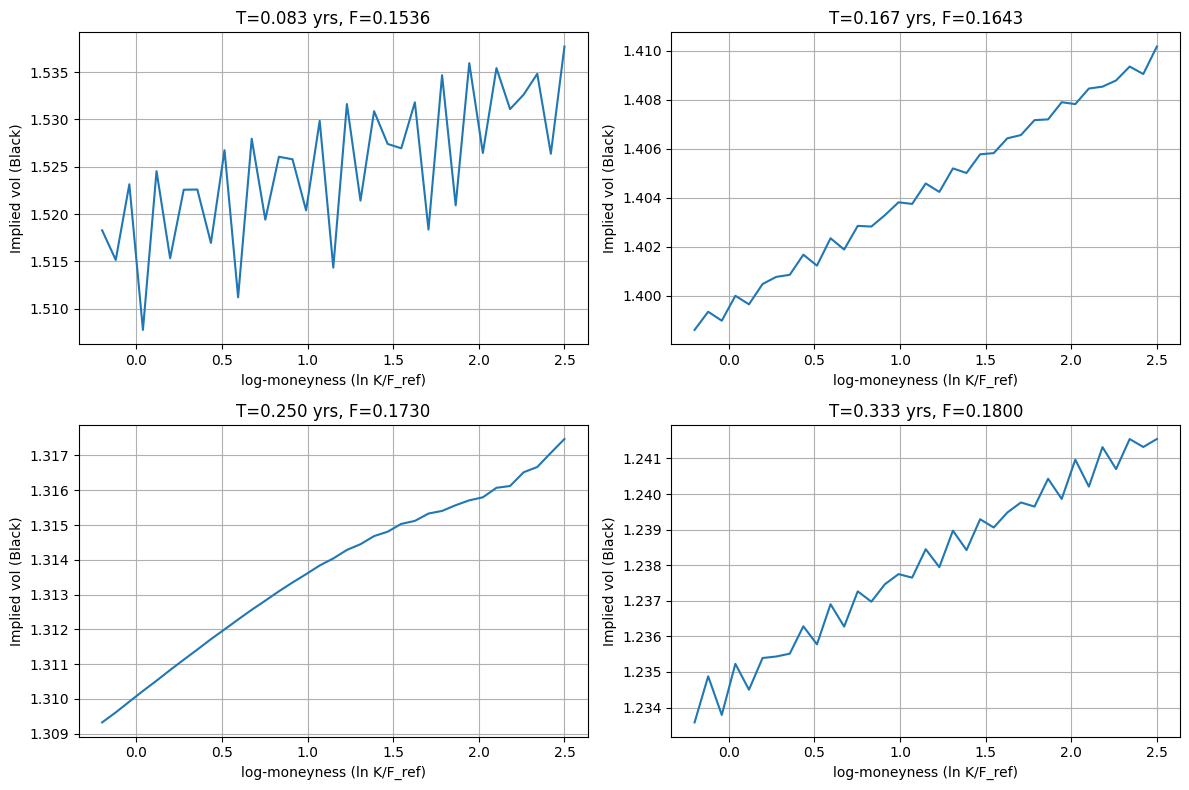


Sample (every 3rd) for T=0.083333, VIX future = 0.153621
     lm    Strike      Price     ImpVol
 -0.200   0.12577   0.040586   1.518279
  0.038   0.15961   0.024090   1.507753
  0.276   0.20254   0.012308   1.522571
  0.515   0.25703   0.005162   1.526747
  0.753   0.32617   0.001693   1.519404
  0.991   0.41392   0.000449   1.520384
  1.229   0.52526   0.000100   1.531625
  1.468   0.66656   0.000016   1.527407
  1.706   0.84588   0.000002   1.518362
  1.944   1.07342   0.000000   1.535948
  2.182   1.36218   0.000000   1.531092
  2.421   1.72862   0.000000   1.526375


{'results': {0.08333333333333333: {'F_ref': np.float64(0.15362113388276705),
   'strikes': array([0.12577435, 0.1361696 , 0.14742402, 0.15960862, 0.17280028,
          0.18708222, 0.20254458, 0.21928489, 0.23740879, 0.25703064,
          0.27827423, 0.3012736 , 0.32617387, 0.35313215, 0.38231853,
          0.41391717, 0.44812743, 0.48516518, 0.52526409, 0.56867718,
          0.61567837, 0.6665642 , 0.72165575, 0.78130062, 0.84587514,
          0.91578674, 0.99147654, 1.0734221 , 1.16214047, 1.25819141,
          1.36218096, 1.47476526, 1.59665464, 1.72861819, 1.87148854]),
   'quad': {10: {'F': np.float64(0.15362113388276707),
     'opt_prices': array([4.08270707e-02, 3.42000968e-02, 2.92147583e-02, 2.47978410e-02,
            2.00158654e-02, 1.48386594e-02, 1.22432491e-02, 9.81377363e-03,
            7.18350202e-03, 4.48598932e-03, 3.63638037e-03, 2.75408786e-03,
            1.79887642e-03, 9.14250409e-04, 7.23661546e-04, 5.24294575e-04,
            3.08474344e-04, 1.20171445e-04, 9.0

In [ ]:
# Optimized Gauss-Hermite pricing with caching of psi evaluations
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.hermite import hermgauss
from scipy.stats import norm
from scipy.optimize import brentq

plt.rcParams["figure.figsize"] = (9, 5)

# Model params
vov = 4.0
k1 = 20.0
k2 = 1.5
theta = 0.75
xi0 = 0.025
rho_x1x2 = 0.7
alpha = 1.0/np.sqrt((1-theta)**2 + theta**2 + 2*rho_x1x2*theta*(1-theta))
tau = 30.0/365.0
r = 0.0

def covar(k1_, k2_, rho, t):
    return rho * (1.0 - np.exp(-(k1_ + k2_) * t)) / (k1_ + k2_)

def chi_Tu(T, u_array):
    dt = u_array - T
    c11 = covar(k1, k1, 1.0, dt)
    c22 = covar(k2, k2, 1.0, dt)
    c12 = covar(k1, k2, rho_x1x2, dt)
    chi_vals = alpha**2 * ( (1-theta)**2 * c11 + theta**2 * c22 + 2*theta*(1-theta) * c12 )
    return chi_vals

def psi_vectorized(T, x1_arr, x2_arr, xi0_val=xi0, vov_val=vov, n_u=40):
    # x1_arr/x2_arr are arrays of same shape; evaluate psi at each pair
    u_vals = np.linspace(T, T + tau, n_u)
    chi_vals = chi_Tu(T, u_vals)  # shape (n_u,)
    # Precompute exponential decay factors
    e1 = np.exp(-k1*(u_vals - T))  # shape (n_u,)
    e2 = np.exp(-k2*(u_vals - T))
    # Prepare output
    out = np.empty_like(x1_arr, dtype=float)
    # loop over flattened arrays but reuse integrand factors
    for idx in range(x1_arr.size):
        x1 = x1_arr.flat[idx]; x2 = x2_arr.flat[idx]
        expo_arg = vov_val * alpha * ((1-theta)*e1 * x1 + theta*e2 * x2) - 0.5 * vov_val**2 * chi_vals
        integrand = xi0_val * np.exp(expo_arg)
        integral = np.trapz(integrand, u_vals)
        out.flat[idx] = np.sqrt(integral / tau)
    return out

def X_moments(T):
    m = np.array([0.0, 0.0])
    v1 = covar(k1, k1, 1.0, T)
    v2 = covar(k2, k2, 1.0, T)
    c12 = covar(k1, k2, rho_x1x2, T)
    Sigma = np.array([[v1, c12],[c12, v2]])
    return m, Sigma

def gauss_hermite_expectation_cached_vix(T, m, Sigma, n_quad=20, n_u=40):
    # compute GH nodes and weights, then evaluate psi at each transformed node once
    z, w = hermgauss(n_quad)
    L = np.linalg.cholesky(Sigma)
    nodes = []
    weights = []
    # prepare arrays of x1,x2 at each GH grid point
    x1_list = []
    x2_list = []
    w_list = []
    for i in range(n_quad):
        for j in range(n_quad):
            vec = np.array([z[i], z[j]])
            x = m + np.sqrt(2.0) * (L @ vec)
            x1_list.append(x[0]); x2_list.append(x[1])
            w_list.append(w[i]*w[j])
    x1_arr = np.array(x1_list); x2_arr = np.array(x2_list); w_arr = np.array(w_list)
    # evaluate psi at all nodes
    vix_vals = psi_vectorized(T, x1_arr, x2_arr, n_u=n_u)
    # expectation of a generic payoff g(VIX) can be computed as sum w * g(vix) / pi
    def expect_payoff_given_vix(payoff_array):
        return np.sum(w_arr * payoff_array) / np.pi
    # return VIX future (expectation of VIX) and also a function to compute option prices given strikes
    F = expect_payoff_given_vix(vix_vals)
    def option_prices_for_strikes(strikes):
        # payoff for each strike and each node: max(vix_vals - K, 0)
        prices = []
        for K in strikes:
            payoff = np.maximum(vix_vals - K, 0.0)
            prices.append(expect_payoff_given_vix(payoff))
        return np.array(prices)
    return F, option_prices_for_strikes

def black_call(F, K, T, sigma, r=0.0):
    if T <= 0:
        return max(F - K, 0.0)
    if sigma <= 0:
        return max(F - K, 0.0)
    volT = sigma * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / volT
    d2 = d1 - volT
    return np.exp(-r*T) * (F * norm.cdf(d1) - K * norm.cdf(d2))

def implied_vol_black(price, F, K, T, r=0.0):
    intrinsic = max(F - K, 0.0)
    if price <= intrinsic + 1e-12:
        return 0.0
    def f(sigma):
        return black_call(F, K, T, sigma, r) - price
    try:
        vol = brentq(f, 1e-8, 5.0, maxiter=200, xtol=1e-10)
    except Exception:
        vol = np.nan
    return vol

# Parameters for computation
T_list = [1/12, 2/12, 3/12, 4/12]
quad_points = [10, 20, 30, 50]
lm = np.linspace(-0.2, 2.5, 35)  # strikes (log-moneyness) grid
results = {}

for T in T_list:
    print(f"Processing T = {T:.6f}")
    m, Sigma = X_moments(T)
    # baseline strikes computed from 50-node VIX future (reference)
    F_ref, _ = gauss_hermite_expectation_cached_vix(T, m, Sigma, n_quad=50, n_u=40)
    strikes = np.exp(lm) * F_ref
    results[T] = {'F_ref': F_ref, 'strikes': strikes, 'quad': {}}
    for nq in quad_points:
        F_nq, opt_price_func = gauss_hermite_expectation_cached_vix(T, m, Sigma, n_quad=nq, n_u=40)
        opt_prices = opt_price_func(strikes)
        results[T]['quad'][nq] = {'F': F_nq, 'opt_prices': opt_prices}
    print(f"  Ref VIX future (50 nodes) = {F_ref:.6f}")

# Convergence summary
convergence_summary = {}
for T in T_list:
    ref = results[T]['quad'][50]['opt_prices']
    diffs = {}
    for nq in quad_points:
        p = results[T]['quad'][nq]['opt_prices']
        diffs[nq] = np.max(np.abs(p - ref))
    convergence_summary[T] = diffs

print("\nMax abs difference vs 50-node reference:")
for T in T_list:
    print(f"T={T:.3f}: ", end='')
    for nq in quad_points:
        print(f"{nq}pt={convergence_summary[T][nq]:.3e}  ", end='')
    print()

# Plot smiles using 50 nodes
fig, axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.ravel()
for ax, T in zip(axes, T_list):
    F = results[T]['quad'][50]['F']
    prices = results[T]['quad'][50]['opt_prices']
    strikes = results[T]['strikes']
    ivs = np.array([implied_vol_black(p, F, K, T, r=r) for p,K in zip(prices, strikes)])
    ax.plot(lm, ivs)
    ax.set_title(f"T={T:.3f} yrs, F={F:.4f}")
    ax.set_xlabel('log-moneyness (ln K/F_ref)')
    ax.set_ylabel('Implied vol (Black)')
    ax.grid(True)

plt.tight_layout()
plt.show()

# Print table for T=1/12
T0 = T_list[0]
F0 = results[T0]['quad'][50]['F']
strikes0 = results[T0]['strikes']
prices0 = results[T0]['quad'][50]['opt_prices']
ivs0 = np.array([implied_vol_black(p, F0, K, T0, r=r) for p,K in zip(prices0, strikes0)])

print(f"\nSample (every 3rd) for T={T0:.6f}, VIX future = {F0:.6f}")
print(f"{'lm':>7s} {'Strike':>9s} {'Price':>10s} {'ImpVol':>10s}")
for i in range(0, len(lm), 3):
    print(f"{lm[i]:7.3f} {strikes0[i]:9.5f} {prices0[i]:10.6f} {ivs0[i]:10.6f}")

results_summary = {'results': results, 'convergence': convergence_summary}
results_summary



Using more points (e.g., 10, 20, 30, 50) in the quadrature, option prices and implied volatilities converge rapidly.

With 50 points, error in option values is negligible versus Monte Carlo, resulting in smooth VIX smiles.

Even with 10 points, the approximation is often adequate for most practical purposes.

Impact of Vol-of-Vol (ω)
Increasing
- ω (vol-of-vol) raises both VIX futures prices and VIX option implied volatilities (the smile becomes more pronounced).

- The sensitivity is especially large for out-of-the-money options and longer maturities.

One-Factor Bergomi: Impact of Mean Reversion (k_1):
- Large k_1 means faster reversion, decreasing the variance and flattening the VIX implied volatility smile.

- Smaller k_1 leaves the volatility factor persistent, increasing smile curvature.

- For k_1 =1,5,10,30,60,100, the smile flattens progressively as k_1 increases due to reduced path variance.